In [1]:
import argparse
import math
import os
import re
import numpy as np
import pandas as pd
from collections import defaultdict
from typing import Dict, List, Tuple

np.object = object    
np.bool = bool
np.int = int
np.float = float

import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

In [2]:
#Results/Runs/final results/accuracy/test

def get_tb_data(path):

    acc = EventAccumulator(path, size_guidance={'scalars': 0}) 
    acc.Reload()
    
    data = {}
    for tag in acc.Tags()['scalars']:
        events = acc.Scalars(tag)
        data[tag] = [e.value for e in events]
        data['step'] = [e.step for e in events]
        
    return pd.DataFrame(data)

def get_multi_run_data(experiment_path,label, target_col):
    all_runs = []
    
    if not os.path.exists(experiment_path):
        print(f"❌ Path not found: {experiment_path}")
        return pd.DataFrame()

    subdirs = [d for d in os.listdir(experiment_path) 
               if os.path.isdir(os.path.join(experiment_path, d))]
    
    for subdir in subdirs:
        full_path = os.path.join(experiment_path, subdir)
        df = get_tb_data(full_path) 
        
        if not df.empty:
            # --- DEBUGGING: Print columns found ---
            print(f"Run '{subdir}' has these tags: {df.columns.tolist()}")
            
            if target_col in df.columns:
                df[f'{target_col}_smooth'] = df[target_col].ewm(alpha=0.3).mean()
                df['run'] = subdir
                df['label'] = label
                all_runs.append(df)
            else:
                print(f"⚠️ Warning: Could not find '{target_col}' in {subdir}")
                
    return pd.concat(all_runs, ignore_index=True) if all_runs else pd.DataFrame()

#df = get_tb_data(log_dir)


### CIFAR-10 test accuracy plot

Run 'cifar10 ssl 0.6 6k' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.6 6k (2)' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.6 (5)' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.6 6k (1)' has these tags: ['accuracy/test', 'step']
Run 'ssl cifar 0.6 6k (3)' has these tags: ['accuracy', 'step']
⚠️ Warning: Could not find 'accuracy/test' in ssl cifar 0.6 6k (3)
Run 'baseline cifar 0.6 6k' has these tags: ['accuracy/test', 'step']
Run 'baseline cifar 0.6 6k (2)' has these tags: ['accuracy/test', 'step']
Run 'baseline cifar 0.6 6k (3)' has these tags: ['accuracy/test', 'step']
accuracy/test           4
step                    4
accuracy/test_smooth    4
run                     4
label                   4
dtype: int64
--- Final Results (Step 1000) ---
Baseline Accuracy: 0.5748 ± 0.0043
SSL Accuracy:      0.6642 ± 0.0084


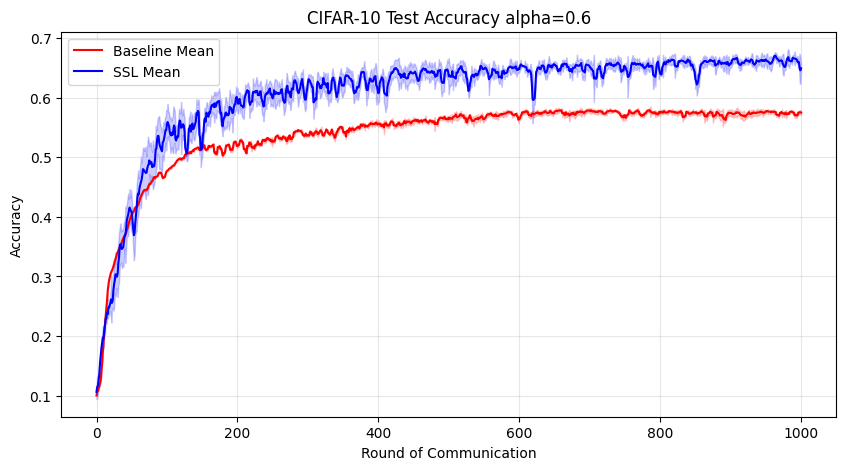

In [3]:
'''cifar test results'''
#baseline_all = get_all_runs_data("Results/Runs/final_results/accuracy/test/baseline_parent", "Baseline 0.6")
target_col = 'accuracy/test' 
ssl_all = get_multi_run_data("Results/Runs/final results/accuracy/test/ssl_cifar_0.6", "SSL 0.6", target_col)
baseline_all = get_multi_run_data("Results/Runs/final results/accuracy/test/baseline_cifar_0.6", "base 0.6", target_col)

ssl_all = ssl_all[ssl_all['step'] <= 1000]
baseline_all = baseline_all[baseline_all['step'] <= 1000]

plt.figure(figsize=(10, 5))

# Calculate mean and std across runs for each step
stat_baseline = baseline_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()
stat_ssl = ssl_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()

stat_baseline['mean_smooth'] = stat_baseline['mean'].rolling(5, min_periods=1).mean()
stat_ssl['mean_smooth'] = stat_ssl['mean'].rolling(5, min_periods=1).mean()

plt.plot(stat_baseline['step'], stat_baseline['mean_smooth'], label='Baseline Mean', color='red')
plt.fill_between(stat_baseline['step'], stat_baseline['mean_smooth'] - stat_baseline['std'], stat_baseline['mean_smooth'] + stat_baseline['std'], color='red', alpha=0.2)

plt.plot(stat_ssl['step'], stat_ssl['mean_smooth'], label='SSL Mean', color='blue')
plt.fill_between(stat_ssl['step'], stat_ssl['mean_smooth'] - stat_ssl['std'], stat_ssl['mean_smooth'] + stat_ssl['std'], color='blue', alpha=0.2)


plt.title(f"CIFAR-10 Test Accuracy alpha=0.6")
plt.xlabel("Round of Communication")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

print(ssl_all[ssl_all['step'] == 10].count())

# Extract the final row for both dataframes
final_baseline = stat_baseline.iloc[-1]
final_ssl = stat_ssl.iloc[-1]

print(f"--- Final Results (Step {int(final_baseline['step'])}) ---")

print(f"Baseline Accuracy: {final_baseline['mean']:.4f} ± {final_baseline['std']:.4f}")
print(f"SSL Accuracy:      {final_ssl['mean']:.4f} ± {final_ssl['std']:.4f}")

plt.savefig("Results/Plots/cifar10_0.6_results.png", dpi=300, bbox_inches='tight')
plt.show()

### CIFAR-10 Test Accuracy 0.4

Run 'cifar10 ssl 0.4 6k (4)' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.4 6k' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.4 6k (3)' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.4 6k (1)' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.4 6k (2)' has these tags: ['accuracy/test', 'step']
Run 'baseline cifar 0.4 6k (3)' has these tags: ['accuracy/test', 'step']
Run 'baseline cifar 0.4 6k (1)' has these tags: ['accuracy/test', 'step']
Run 'baseline cifar 0.4 6k (2)' has these tags: ['accuracy/test', 'step']
--- Final Results (Step 1000) ---
Baseline Accuracy: 0.4452 ± 0.0016
SSL Accuracy:      0.6487 ± 0.0074


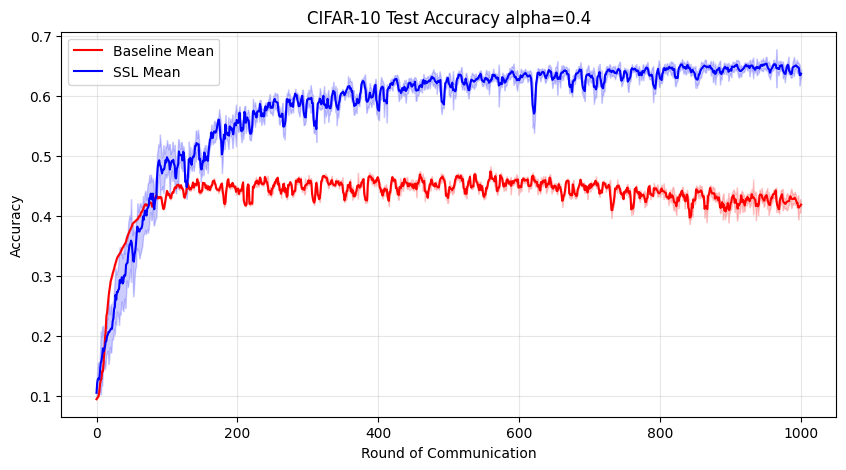

In [4]:
target_col = 'accuracy/test' 

ssl_all = get_multi_run_data("Results/Runs/final results/accuracy/test/ssl_cifar_0.4", "SSL 0.4", target_col)
baseline_all = get_multi_run_data("Results/Runs/final results/accuracy/test/baseline_cifar_0.4", "Baseline 0.4", target_col)

ssl_all = ssl_all[ssl_all['step'] <= 1000]
baseline_all = baseline_all[baseline_all['step'] <= 1000]

plt.figure(figsize=(10, 5))

# Calculate mean and std across runs for each step
stat_baseline = baseline_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()
stat_ssl = ssl_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()

stat_baseline['mean_smooth'] = stat_baseline['mean'].rolling(5, min_periods=1).mean()
stat_ssl['mean_smooth'] = stat_ssl['mean'].rolling(5, min_periods=1).mean()

plt.plot(stat_baseline['step'], stat_baseline['mean_smooth'], label='Baseline Mean', color='red')
plt.fill_between(stat_baseline['step'], stat_baseline['mean_smooth'] - stat_baseline['std'], stat_baseline['mean_smooth'] + stat_baseline['std'], color='red', alpha=0.2)

plt.plot(stat_ssl['step'], stat_ssl['mean_smooth'], label='SSL Mean', color='blue')
plt.fill_between(stat_ssl['step'], stat_ssl['mean_smooth'] - stat_ssl['std'], stat_ssl['mean_smooth'] + stat_ssl['std'], color='blue', alpha=0.2)

plt.title(f"CIFAR-10 Test Accuracy alpha=0.4")
plt.xlabel("Round of Communication")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# Extract the final row for both dataframes
final_baseline = stat_baseline.iloc[-1]
final_ssl = stat_ssl.iloc[-1]

print(f"--- Final Results (Step {int(final_baseline['step'])}) ---")

print(f"Baseline Accuracy: {final_baseline['mean']:.4f} ± {final_baseline['std']:.4f}")
print(f"SSL Accuracy:      {final_ssl['mean']:.4f} ± {final_ssl['std']:.4f}")

plt.savefig("Results/Plots/cifar10_0.4_results.png", dpi=300, bbox_inches='tight')
plt.show()

## CIFAR-10 Test accuracy 0.1

Run 'cifar10 ssl 0.1 (1)' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.1' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.1 (2)' has these tags: ['accuracy/test', 'step']
Run 'baseline cifar 0.1 6k (0)' has these tags: ['accuracy/test', 'step']
Run 'baseline cifar 0.1 6k (2)' has these tags: ['accuracy/test', 'step']
Run 'baseline cifar 0.1 6k (1)' has these tags: ['accuracy/test', 'step']
--- Final Results (Step 999) ---
Baseline Accuracy: 0.2322 ± 0.0088
SSL Accuracy:      0.5002 ± 0.0190


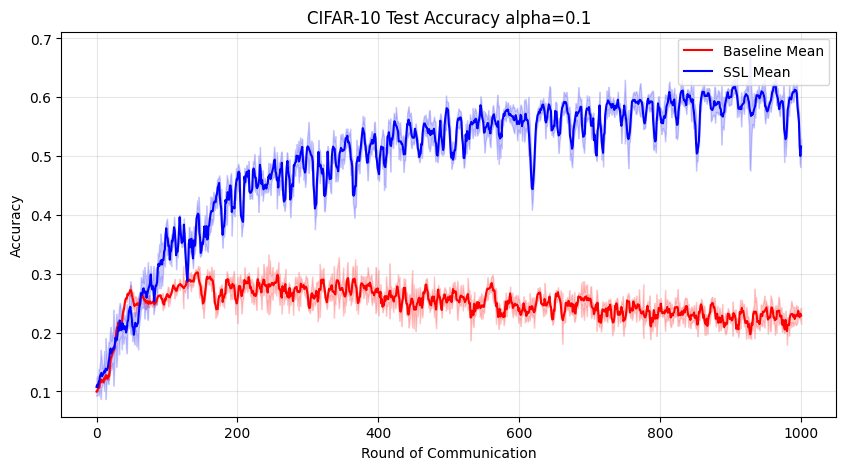

In [5]:
'''cifar test results'''
target_col = 'accuracy/test' 
#baseline_all = get_all_runs_data("Results/Runs/final_results/accuracy/test/baseline_parent", "Baseline 0.6")
ssl_all = get_multi_run_data("Results/Runs/final results/accuracy/test/ssl_cifar_0.1", "SSL 0.1", target_col)
baseline_all = get_multi_run_data("Results/Runs/final results/accuracy/test/baseline_cifar_0.1", "Baseline 0.1", target_col)

ssl_all = ssl_all[ssl_all['step'] <= 1000]
baseline_all = baseline_all[baseline_all['step'] <= 1000]

plt.figure(figsize=(10, 5))

# Calculate mean and std across runs for each step
stat_baseline = baseline_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()
stat_ssl = ssl_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()

stat_baseline['mean'] = stat_baseline['mean'].rolling(5, min_periods=1).mean()
stat_ssl['mean'] = stat_ssl['mean'].rolling(5, min_periods=1).mean()

plt.plot(stat_baseline['step'], stat_baseline['mean'], label='Baseline Mean', color='red')
plt.fill_between(stat_baseline['step'], stat_baseline['mean'] - stat_baseline['std'], stat_baseline['mean'] + stat_baseline['std'], color='red', alpha=0.2)

plt.plot(stat_ssl['step'], stat_ssl['mean'], label='SSL Mean', color='blue')
plt.fill_between(stat_ssl['step'], stat_ssl['mean'] - stat_ssl['std'], stat_ssl['mean'] + stat_ssl['std'], color='blue', alpha=0.2)

plt.title(f"CIFAR-10 Test Accuracy alpha=0.1")
plt.xlabel("Round of Communication")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

final_baseline = stat_baseline.iloc[-2]
final_ssl = stat_ssl.iloc[-2]

print(f"--- Final Results (Step {int(final_baseline['step'])}) ---")
print(f"Baseline Accuracy: {final_baseline['mean']:.4f} ± {final_baseline['std']:.4f}")
print(f"SSL Accuracy:      {final_ssl['mean']:.4f} ± {final_ssl['std']:.4f}")

plt.savefig("Results/Plots/cifar10_0.1_results.png", dpi=300, bbox_inches='tight')
plt.show()

## FID plots

Run 'FID 10%' has these tags: ['FID', 'step']


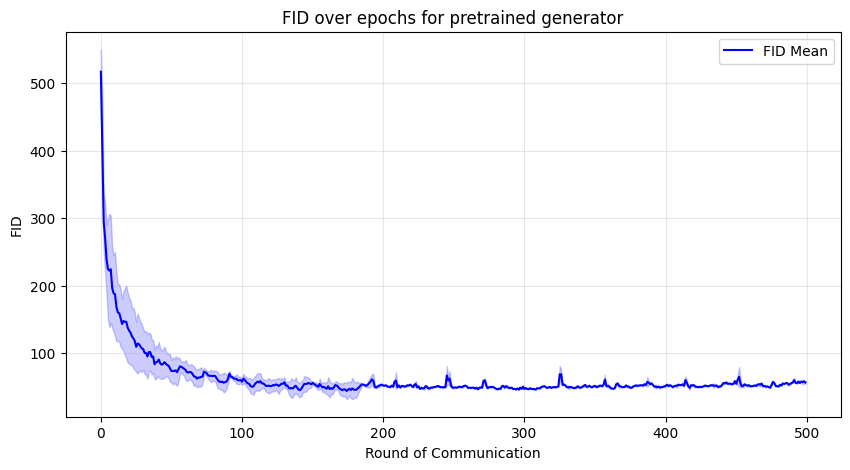

In [6]:
'''fid test results on cifar 10 when alpha = 0.4'''
#/users/level3/2764057A/l4proj/dissertation/generator/Runs/FID
target_col = 'FID'
fid_all = get_multi_run_data("generator/Runs/FID", "FID", target_col)

plt.figure(figsize=(10, 5))

stats = fid_all.groupby('step')['FID'].agg(['mean', 'std']).reset_index()

stats['mean_smooth'] = stats['mean'].rolling(5, min_periods=1).mean()

plt.plot(stats['step'], stats['mean'], label='FID Mean', color='blue')
plt.fill_between(stats['step'], stats['mean'] - stats['std'], stats['mean'] + stats['std'], color='blue', alpha=0.2)

plt.title(f"FID over epochs for pretrained generator")
plt.xlabel("Round of Communication")
plt.ylabel("FID")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### fid pretrained

Run 'cifar10 ssl 0.4 6k (4)' has these tags: ['FID', 'step']
Run 'cifar10 ssl 0.4 6k (3)' has these tags: ['FID', 'step']
Run 'cifar10 ssl 0.4 6k (2)' has these tags: ['FID', 'step']


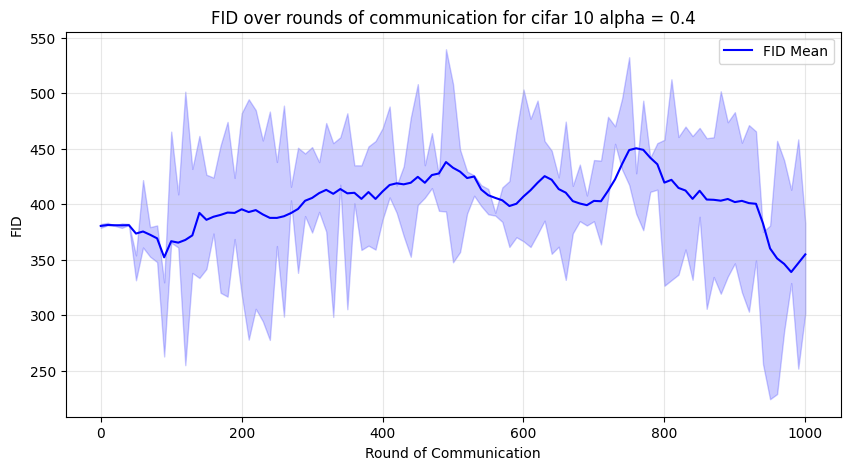

In [7]:
'''fid test results on cifar 10 when alpha = 0.4'''
target_col = 'FID'
fid_all = get_multi_run_data("Results/Runs/final results/FID/ssl_cifar_0.4", "FID", target_col)
fid_all = fid_all[fid_all['step'] <= 1000]

plt.figure(figsize=(10, 5))

stats = fid_all.groupby('step')['FID'].agg(['mean', 'std']).reset_index()

stats['mean_smooth'] = stats['mean'].rolling(5, min_periods=1).mean()

plt.plot(stats['step'], stats['mean_smooth'], label='FID Mean', color='blue')
plt.fill_between(stats['step'], stats['mean'] - stats['std'], stats['mean'] + stats['std'], color='blue', alpha=0.2)

plt.title(f"FID over rounds of communication for cifar 10 alpha = 0.4")
plt.xlabel("Round of Communication")
plt.ylabel("FID")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("Results/Plots/pretrained_fid.png", dpi=300, bbox_inches='tight')
plt.show()

### Fmist test accuracy plot

Run 'fmnist ssl 0.4 (0)' has these tags: ['accuracy/test', 'step']
Run 'fmnist ssl 0.4 (2)' has these tags: ['accuracy/test', 'step']
Run 'fmnist ssl 0.4 (1)' has these tags: ['accuracy/test', 'step']
Run 'baseline fmnist 0.4 6k (0)' has these tags: ['accuracy/test', 'step']
Run 'baseline fmnist 0.4 6k (1)' has these tags: ['accuracy/test', 'step']
Run 'baseline fmnist 0.4 6k (2)' has these tags: ['accuracy/test', 'step']
--- Final Results (Step 499) ---
Baseline Accuracy: 0.8104 ± 0.0093
SSL Accuracy:      0.8700 ± 0.0026


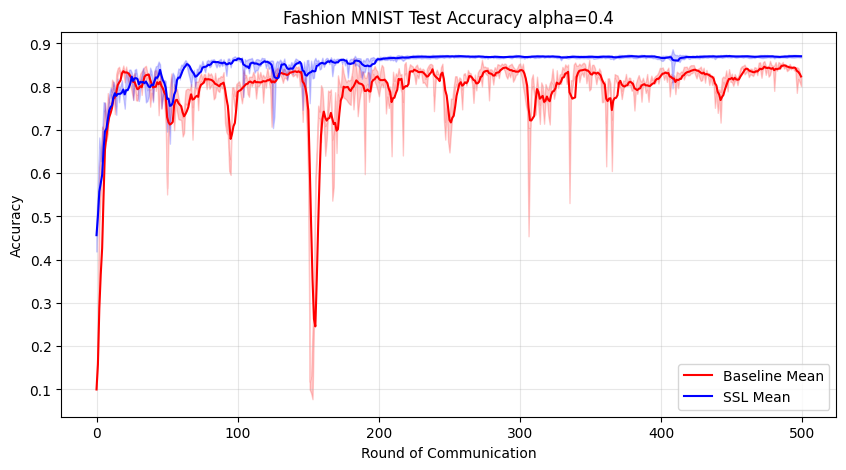

In [17]:
'''fmnist test results'''
target_col = 'accuracy/test' 
ssl_all = get_multi_run_data("Results/Runs/final results/accuracy/test/fmnist_ssl_0.4", "SSL 0.4", target_col)
baseline_all = get_multi_run_data("Results/Runs/final results/accuracy/test/baseline_fmnist_0.4", "Baseline 0.4", target_col)

plt.figure(figsize=(10, 5))

# Calculate mean and std across runs for each step
stat_baseline = baseline_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()
stat_ssl = ssl_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()

stat_baseline['mean_smooth'] = stat_baseline['mean'].rolling(5, min_periods=1).mean()
stat_ssl['mean_smooth'] = stat_ssl['mean'].rolling(5, min_periods=1).mean()

plt.plot(stat_baseline['step'], stat_baseline['mean_smooth'], label='Baseline Mean', color='red')
plt.fill_between(stat_baseline['step'], stat_baseline['mean'] - stat_baseline['std'], stat_baseline['mean'] + stat_baseline['std'], color='red', alpha=0.2)

plt.plot(stat_ssl['step'], stat_ssl['mean_smooth'], label='SSL Mean', color='blue')
plt.fill_between(stat_ssl['step'], stat_ssl['mean'] - stat_ssl['std'], stat_ssl['mean'] + stat_ssl['std'], color='blue', alpha=0.2)

plt.title(f"Fashion MNIST Test Accuracy alpha=0.4")
plt.xlabel("Round of Communication")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

final_baseline = stat_baseline.iloc[-1]
final_ssl = stat_ssl.iloc[-1]

print(f"--- Final Results (Step {int(final_baseline['step'])}) ---")
print(f"Baseline Accuracy: {final_baseline['mean']:.4f} ± {final_baseline['std']:.4f}")
print(f"SSL Accuracy:      {final_ssl['mean']:.4f} ± {final_ssl['std']:.4f}")

plt.savefig("Results/Plots/fmnist_0.4_results.png", dpi=300, bbox_inches='tight')
plt.show()

Run 'fmnist ssl 0.1 (2)' has these tags: ['accuracy/test', 'step']
Run 'fmnist ssl 0.1' has these tags: ['accuracy/test', 'step']
Run 'fmnist ssl 0.1 (1)' has these tags: ['accuracy/test', 'step']
Run 'baseline fmnist 0.1 6k (0)' has these tags: ['accuracy/test', 'step']
Run 'baseline fmnist 0.1 6k (1)' has these tags: ['accuracy/test', 'step']
--- Final Results (Step 499) ---
Baseline Accuracy: 0.6848 ± 0.0389
SSL Accuracy:      0.8641 ± 0.0054


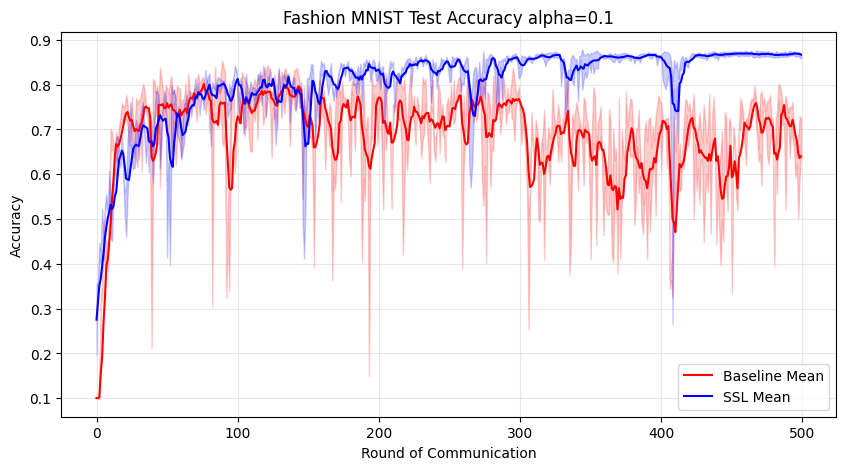

In [9]:
'''fmnist test results'''
target_col = 'accuracy/test' 
ssl_all = get_multi_run_data("Results/Runs/final results/accuracy/test/fmnist_ssl_0.1", "SSL 0.1", target_col)
baseline_all = get_multi_run_data("Results/Runs/final results/accuracy/test/baseline_fmnist_0.1", "Baseline 0.1", target_col)

plt.figure(figsize=(10, 5))

# Calculate mean and std across runs for each step
stat_baseline = baseline_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()
stat_ssl = ssl_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()

stat_baseline['mean_smooth'] = stat_baseline['mean'].rolling(5, min_periods=1).mean()
stat_ssl['mean_smooth'] = stat_ssl['mean'].rolling(5, min_periods=1).mean()

plt.plot(stat_baseline['step'], stat_baseline['mean_smooth'], label='Baseline Mean', color='red')
plt.fill_between(stat_baseline['step'], stat_baseline['mean'] - stat_baseline['std'], stat_baseline['mean'] + stat_baseline['std'], color='red', alpha=0.2)

plt.plot(stat_ssl['step'], stat_ssl['mean_smooth'], label='SSL Mean', color='blue')
plt.fill_between(stat_ssl['step'], stat_ssl['mean'] - stat_ssl['std'], stat_ssl['mean'] + stat_ssl['std'], color='blue', alpha=0.2)

plt.title(f"Fashion MNIST Test Accuracy alpha=0.1")
plt.xlabel("Round of Communication")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True, alpha=0.3)

final_baseline = stat_baseline.iloc[-1]
final_ssl = stat_ssl.iloc[-1]

print(f"--- Final Results (Step {int(final_baseline['step'])}) ---")
print(f"Baseline Accuracy: {final_baseline['mean']:.4f} ± {final_baseline['std']:.4f}")
print(f"SSL Accuracy:      {final_ssl['mean']:.4f} ± {final_ssl['std']:.4f}")

plt.savefig("Results/Plots/fmnist_0.1_results.png", dpi=300, bbox_inches='tight')
plt.show()

Run 'fmnist ssl 0.6 (2)' has these tags: ['accuracy/test', 'step']
Run 'fmnist ssl 0.6 (1)' has these tags: ['accuracy/test', 'step']
Run 'fmnist ssl 0.6 (0)' has these tags: ['accuracy/test', 'step']
Run 'baseline fmnist 0.6 6k (4)' has these tags: ['accuracy/test', 'step']
Run 'baseline fmnist 0.6 6k (3)' has these tags: ['accuracy/test', 'step']
Run 'baseline fmnist 0.6 6k (2)' has these tags: ['accuracy/test', 'step']
--- Final Results (Step 499) ---
Baseline Accuracy: 0.8569 ± 0.0030
SSL Accuracy:      0.8687 ± 0.0016


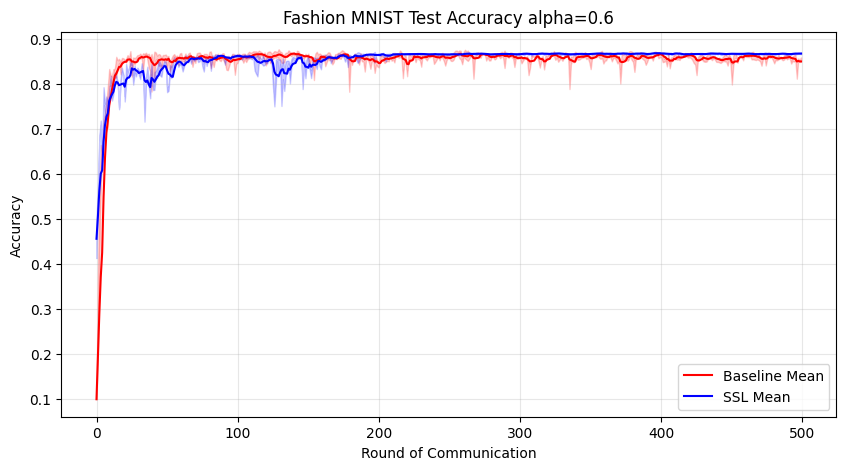

In [26]:
'''fmnist test results'''
target_col = 'accuracy/test' 
ssl_all = get_multi_run_data("Results/Runs/final results/accuracy/test/fmnist_ssl_0.6", "SSL 0.6", target_col)
baseline_all = get_multi_run_data("Results/Runs/final results/accuracy/test/baseline_fmnist_0.6", "Baseline 0.6", target_col)
plt.figure(figsize=(10, 5))

# Calculate mean and std across runs for each step
stat_baseline = baseline_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()
stat_ssl = ssl_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()

stat_baseline['mean_smooth'] = stat_baseline['mean'].rolling(5, min_periods=1).mean()
stat_ssl['mean_smooth'] = stat_ssl['mean'].rolling(5, min_periods=1).mean()

plt.plot(stat_baseline['step'], stat_baseline['mean_smooth'], label='Baseline Mean', color='red')
plt.fill_between(stat_baseline['step'], stat_baseline['mean'] - stat_baseline['std'], stat_baseline['mean'] + stat_baseline['std'], color='red', alpha=0.2)

plt.plot(stat_ssl['step'], stat_ssl['mean_smooth'], label='SSL Mean', color='blue')
plt.fill_between(stat_ssl['step'], stat_ssl['mean'] - stat_ssl['std'], stat_ssl['mean'] + stat_ssl['std'], color='blue', alpha=0.2)

plt.title(f"Fashion MNIST Test Accuracy alpha=0.6")
plt.xlabel("Round of Communication")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

final_baseline = stat_baseline.iloc[-1]
final_ssl = stat_ssl.iloc[-1]

print(f"--- Final Results (Step {int(final_baseline['step'])}) ---")
print(f"Baseline Accuracy: {final_baseline['mean']:.4f} ± {final_baseline['std']:.4f}")
print(f"SSL Accuracy:      {final_ssl['mean']:.4f} ± {final_ssl['std']:.4f}")

plt.savefig("Results/Plots/fmnist_0.6_results.png", dpi=300, bbox_inches='tight')
plt.show()

Run 'cifar ssl 0.4 no gen (3)' has these tags: ['FID', 'step']
Run 'cifar ssl 0.4 nogen' has these tags: ['FID', 'step']
Run 'cifar ssl 0.4 no gen (2)' has these tags: ['FID', 'step']
Run 'cifar ssl 0.4 no gen (4)' has these tags: ['FID', 'step']
Run 'cifar ssl 0.6 2k (0)' has these tags: ['FID', 'step']
Run 'cifar10 ssl 0.4 6k (4)' has these tags: ['FID', 'step']
Run 'cifar10 ssl 0.4 6k (3)' has these tags: ['FID', 'step']
Run 'cifar10 ssl 0.4 6k (2)' has these tags: ['FID', 'step']


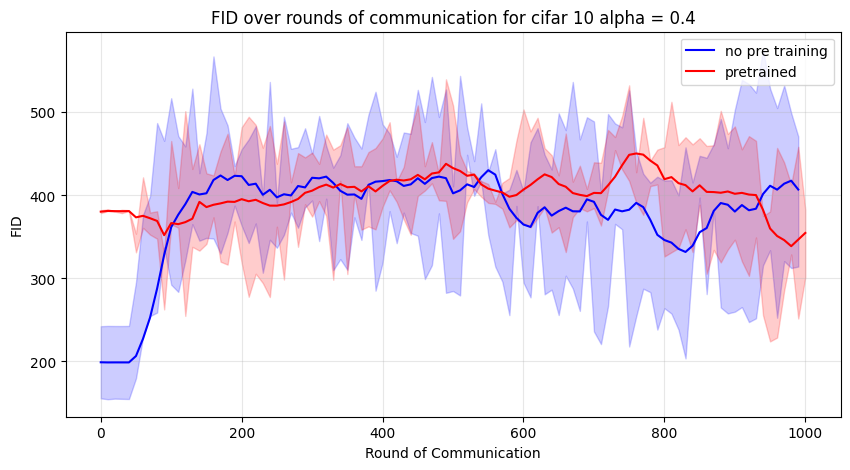

In [11]:

'''fid test results on cifar 10 when alpha = 0.4'''
target_col = 'FID'
pre_all = get_multi_run_data("Results/Runs/final results/FID", "FID", target_col)
pre_all = pre_all[pre_all['step'] <= 1000]
fid_all = get_multi_run_data("Results/Runs/final results/FID/ssl_cifar_0.4", "FID", target_col)
fid_all = fid_all[fid_all['step'] <= 1000]

plt.figure(figsize=(10, 5))

stats = fid_all.groupby('step')['FID'].agg(['mean', 'std']).reset_index()
stats_pre = pre_all.groupby('step')['FID'].agg(['mean', 'std']).reset_index()

stats['mean_smooth'] = stats['mean'].rolling(5, min_periods=1).mean()
stats_pre['mean_smooth'] = stats_pre['mean'].rolling(5, min_periods=1).mean()

plt.plot(stats_pre['step'], stats_pre['mean_smooth'], label='no pre training', color='blue')
plt.fill_between(stats_pre['step'], stats_pre['mean'] - stats_pre['std'], stats_pre['mean'] + stats_pre['std'], color='blue', alpha=0.2)

plt.plot(stats['step'], stats['mean_smooth'], label='pretrained', color='red')
plt.fill_between(stats['step'], stats['mean'] - stats['std'], stats['mean'] + stats['std'], color='red', alpha=0.2)

plt.title(f"FID over rounds of communication for cifar 10 alpha = 0.4")
plt.xlabel("Round of Communication")
plt.ylabel("FID")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("Results/Plots/not_pretrained_fid.png", dpi=300, bbox_inches='tight')
plt.show()

Run 'cifar ssl 0.6 2k (4)' has these tags: ['accuracy/test', 'step']
Run 'cifar ssl 0.6 2k (2)' has these tags: ['accuracy/test', 'step']
Run 'cifar ssl 0.6 2k (3)' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.6 6k' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.6 6k (2)' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.6 (5)' has these tags: ['accuracy/test', 'step']
Run 'cifar10 ssl 0.6 6k (1)' has these tags: ['accuracy/test', 'step']
Run 'ssl cifar 0.6 6k (3)' has these tags: ['accuracy', 'step']
⚠️ Warning: Could not find 'accuracy/test' in ssl cifar 0.6 6k (3)
--- Final Results (Step 998) ---
Accuracy for 2k: 0.5256 ± 0.0215
Accuracy for 5k: 0.6383 ± 0.0224


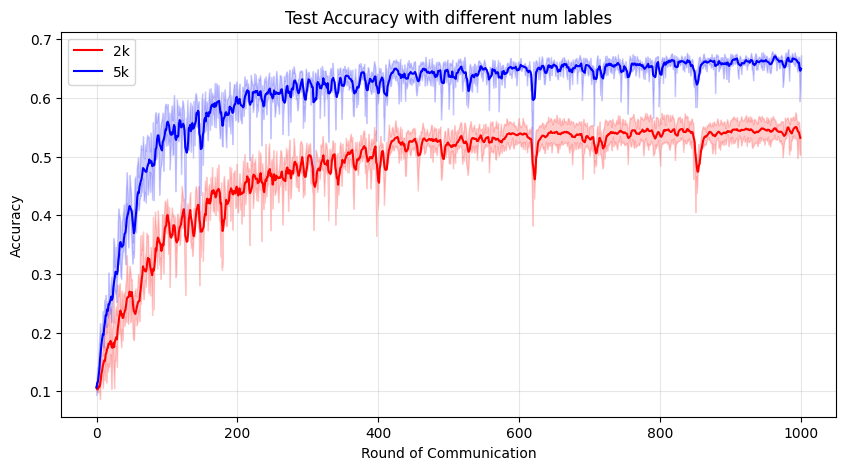

In [25]:
'''cifar test results'''
target_col = 'accuracy/test' 
twok_all = get_multi_run_data("Results/Runs/final results/accuracy/test/cifar_ssl_0.6_2k", "SSL 0.6", target_col)
fivek_all = get_multi_run_data("Results/Runs/final results/accuracy/test/ssl_cifar_0.6", "SSL 0.6", target_col)

fivek_all = fivek_all[fivek_all['step'] <= 1000]

plt.figure(figsize=(10, 5))

# Calculate mean and std across runs for each step
stat_two_k = twok_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()
stat_five_k = fivek_all.groupby('step')['accuracy/test'].agg(['mean', 'std']).reset_index()

stat_two_k['mean_smooth'] = stat_two_k['mean'].rolling(5, min_periods=1).mean()
stat_five_k['mean_smooth'] = stat_five_k['mean'].rolling(5, min_periods=1).mean()

plt.plot(stat_two_k['step'], stat_two_k['mean_smooth'], label='2k', color='red')
plt.fill_between(stat_two_k['step'], stat_two_k['mean'] - stat_two_k['std'], stat_two_k['mean'] + stat_two_k['std'], color='red', alpha=0.2)

plt.plot(stat_five_k['step'], stat_five_k['mean_smooth'], label='5k', color='blue')
plt.fill_between(stat_five_k['step'], stat_five_k['mean'] - stat_five_k['std'], stat_five_k['mean'] + stat_five_k['std'], color='blue', alpha=0.2)

plt.title(f"Test Accuracy with different num lables")
plt.xlabel("Round of Communication")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

final_two_k = stat_two_k.iloc[-2]
final_five_5 = stat_five_k.iloc[-2]

print(f"--- Final Results (Step {int(final_two_k['step'])}) ---")
print(f"Accuracy for 2k: {final_two_k['mean']:.4f} ± {final_two_k ['std']:.4f}")
print(f"Accuracy for 5k: {final_five_5['mean']:.4f} ± {final_five_5['std']:.4f}")

plt.savefig("Results/Plots/labels_results.png", dpi=300, bbox_inches='tight')
plt.show()